In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("energy_data.csv")
print(df.head())

   Global_active_power  Global_reactive_power  Voltage  Global_intensity  \
0                0.152                  0.124   241.20               0.8   
1                0.242                  0.000   239.55               1.0   
2                0.334                  0.072   243.01               1.6   
3                1.350                  0.000   242.27               5.6   
4                1.404                  0.206   238.85               5.8   

   Sub_metering_1  Sub_metering_2  Sub_metering_3         datetime  
0               0               0               1  8/16/2008 13:14  
1               0               0               1  1/29/2010 21:36  
2               0               0               1   9/5/2010 17:46  
3               0               0              19   3/26/2010 9:52  
4               0               0              18  9/15/2009 11:41  


In [3]:
df['datetime'] = pd.to_datetime(df['datetime'])

df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month

In [4]:
df = df.dropna()

In [5]:
features = [
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3',
    'hour'
]

X = df[features].values   # convert to numpy
y = df['Global_active_power'].values

In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [7]:
X = scaler.fit_transform(X)

num_clients = 10
X_splits = np.array_split(X, num_clients)
y_splits = np.array_split(y, num_clients)
client_data = list(zip(X_splits, y_splits))

In [8]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

global_model = Ridge(alpha=1.0)
global_model.fit(X, y)

global_weights = global_model.coef_.copy()

In [9]:
rounds = 30
loss_fedavg = []

global_weights_fedavg = global_weights.copy()

for r in range(rounds):

    local_weights = []
    local_losses = []

    for X_client, y_client in client_data:

        # Add small variation (important)
        X_client = X_client + np.random.normal(0, 0.01, X_client.shape)

        model = Ridge(alpha=1.0)
        model.coef_ = global_weights_fedavg.copy()
        model.intercept_ = global_model.intercept_

        model.fit(X_client, y_client)

        local_weights.append(model.coef_)

        preds = model.predict(X_client)
        loss = mean_squared_error(y_client, preds)
        local_losses.append(loss)

    # FedAvg aggregation
    global_weights_fedavg = np.mean(local_weights, axis=0)

    avg_loss = np.mean(local_losses)
    loss_fedavg.append(avg_loss)

    print(f"[FedAvg] Round {r+1}: {avg_loss:.6f}")

[FedAvg] Round 1: 0.002079
[FedAvg] Round 2: 0.002068
[FedAvg] Round 3: 0.002071
[FedAvg] Round 4: 0.002059
[FedAvg] Round 5: 0.002071
[FedAvg] Round 6: 0.002070
[FedAvg] Round 7: 0.002065
[FedAvg] Round 8: 0.002071
[FedAvg] Round 9: 0.002063
[FedAvg] Round 10: 0.002066
[FedAvg] Round 11: 0.002068
[FedAvg] Round 12: 0.002069
[FedAvg] Round 13: 0.002063
[FedAvg] Round 14: 0.002069
[FedAvg] Round 15: 0.002074
[FedAvg] Round 16: 0.002062
[FedAvg] Round 17: 0.002064
[FedAvg] Round 18: 0.002072
[FedAvg] Round 19: 0.002070
[FedAvg] Round 20: 0.002070
[FedAvg] Round 21: 0.002059
[FedAvg] Round 22: 0.002060
[FedAvg] Round 23: 0.002067
[FedAvg] Round 24: 0.002061
[FedAvg] Round 25: 0.002066
[FedAvg] Round 26: 0.002066
[FedAvg] Round 27: 0.002068
[FedAvg] Round 28: 0.002064
[FedAvg] Round 29: 0.002067
[FedAvg] Round 30: 0.002065


In [10]:
loss_fedprox = []
global_weights_fedprox = global_weights.copy()

mu = 0.001   # proximal strength

for r in range(rounds):

    local_weights = []
    local_losses = []

    for X_client, y_client in client_data:

        # Add small variation
        X_client = X_client + np.random.normal(0, 0.01, X_client.shape)

        model = Ridge(alpha=1.0)
        model.coef_ = global_weights_fedprox.copy()
        model.intercept_ = global_model.intercept_

        model.fit(X_client, y_client)

        # 🔵 FedProx (core idea)
        # penalize deviation from global model
        model.coef_ = model.coef_ - mu * (model.coef_ - global_weights_fedprox)

        local_weights.append(model.coef_)

        preds = model.predict(X_client)
        loss = mean_squared_error(y_client, preds)
        local_losses.append(loss)

    # Aggregation (same as FedAvg)
    global_weights_fedprox = np.mean(local_weights, axis=0)

    avg_loss = np.mean(local_losses)
    loss_fedprox.append(avg_loss)

    print(f"[FedProx] Round {r+1}: {avg_loss:.6f}")

[FedProx] Round 1: 0.002067
[FedProx] Round 2: 0.002067
[FedProx] Round 3: 0.002065
[FedProx] Round 4: 0.002069
[FedProx] Round 5: 0.002065
[FedProx] Round 6: 0.002070
[FedProx] Round 7: 0.002068
[FedProx] Round 8: 0.002067
[FedProx] Round 9: 0.002061
[FedProx] Round 10: 0.002070
[FedProx] Round 11: 0.002063
[FedProx] Round 12: 0.002069
[FedProx] Round 13: 0.002069
[FedProx] Round 14: 0.002069
[FedProx] Round 15: 0.002071
[FedProx] Round 16: 0.002077
[FedProx] Round 17: 0.002063
[FedProx] Round 18: 0.002067
[FedProx] Round 19: 0.002063
[FedProx] Round 20: 0.002070
[FedProx] Round 21: 0.002065
[FedProx] Round 22: 0.002070
[FedProx] Round 23: 0.002071
[FedProx] Round 24: 0.002066
[FedProx] Round 25: 0.002070
[FedProx] Round 26: 0.002067
[FedProx] Round 27: 0.002070
[FedProx] Round 28: 0.002063
[FedProx] Round 29: 0.002067
[FedProx] Round 30: 0.002061


In [11]:
loss_hybrid = []
global_weights_hybrid = global_weights.copy()

for r in range(rounds):

    local_weights = []
    local_losses = []

    for X_client, y_client in client_data:

        # Add variation
        X_client = X_client + np.random.normal(0, 0.01, X_client.shape)

        model = Ridge(alpha=1.0)
        model.coef_ = global_weights_hybrid.copy()
        model.intercept_ = global_model.intercept_

        model.fit(X_client, y_client)

        # FedProx term
        mu = 0.001
        model.coef_ = model.coef_ - mu * (model.coef_ - global_weights_hybrid)

        local_weights.append(model.coef_)

        preds = model.predict(X_client)
        loss = mean_squared_error(y_client, preds)
        local_losses.append(loss)

    # FedAvg aggregation
    global_weights_hybrid = np.mean(local_weights, axis=0)

    avg_loss = np.mean(local_losses)
    loss_hybrid.append(avg_loss)

    print(f"[Hybrid] Round {r+1}: {avg_loss:.6f}")

[Hybrid] Round 1: 0.002068
[Hybrid] Round 2: 0.002069
[Hybrid] Round 3: 0.002069
[Hybrid] Round 4: 0.002062
[Hybrid] Round 5: 0.002066
[Hybrid] Round 6: 0.002064
[Hybrid] Round 7: 0.002068
[Hybrid] Round 8: 0.002071
[Hybrid] Round 9: 0.002069
[Hybrid] Round 10: 0.002072
[Hybrid] Round 11: 0.002072
[Hybrid] Round 12: 0.002068
[Hybrid] Round 13: 0.002069
[Hybrid] Round 14: 0.002068
[Hybrid] Round 15: 0.002071
[Hybrid] Round 16: 0.002069
[Hybrid] Round 17: 0.002067
[Hybrid] Round 18: 0.002067
[Hybrid] Round 19: 0.002067
[Hybrid] Round 20: 0.002067
[Hybrid] Round 21: 0.002062
[Hybrid] Round 22: 0.002074
[Hybrid] Round 23: 0.002068
[Hybrid] Round 24: 0.002060
[Hybrid] Round 25: 0.002074
[Hybrid] Round 26: 0.002071
[Hybrid] Round 27: 0.002065
[Hybrid] Round 28: 0.002070
[Hybrid] Round 29: 0.002068
[Hybrid] Round 30: 0.002069


In [12]:
# Use final model (Hybrid)
global_model.coef_ = global_weights_hybrid

# Generate predictions
y_pred = global_model.predict(X)

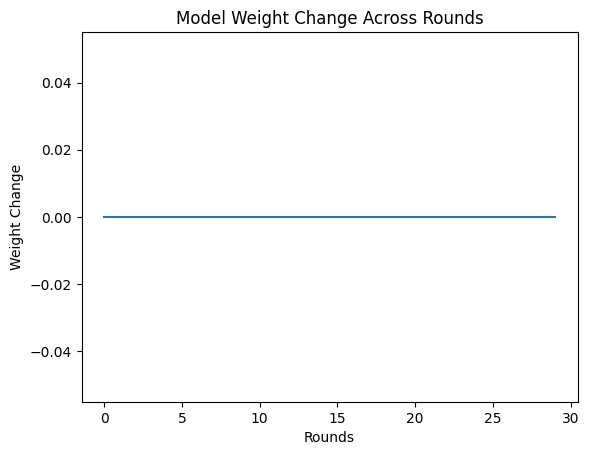

In [13]:
weight_change = []

prev_weights = global_weights.copy()

for w in loss_hybrid:
    change = np.linalg.norm(global_weights - prev_weights)
    weight_change.append(change)
    prev_weights = global_weights.copy()

plt.plot(weight_change)
plt.title("Model Weight Change Across Rounds")
plt.xlabel("Rounds")
plt.ylabel("Weight Change")
plt.show()

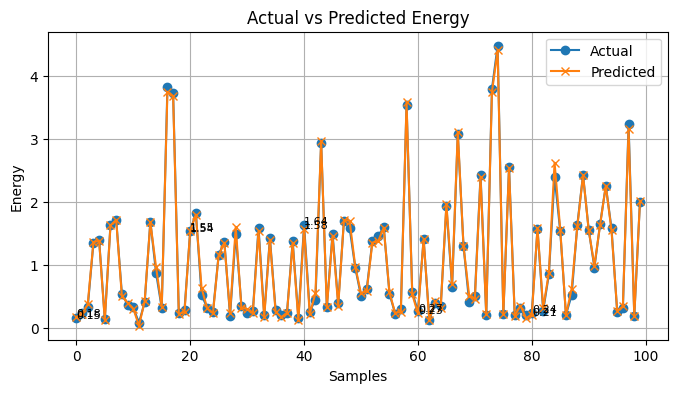

In [14]:
plt.figure(figsize=(8,4))

plt.plot(y[:100], label="Actual", marker='o')
plt.plot(y_pred[:100], label="Predicted", marker='x')

plt.legend()
plt.title("Actual vs Predicted Energy")

# Show few values
for i in range(0, 100, 20):
    plt.text(i, y[i], f"{y[i]:.2f}", fontsize=8)
    plt.text(i, y_pred[i], f"{y_pred[i]:.2f}", fontsize=8)

plt.xlabel("Samples")
plt.ylabel("Energy")
plt.grid(True)
plt.show()

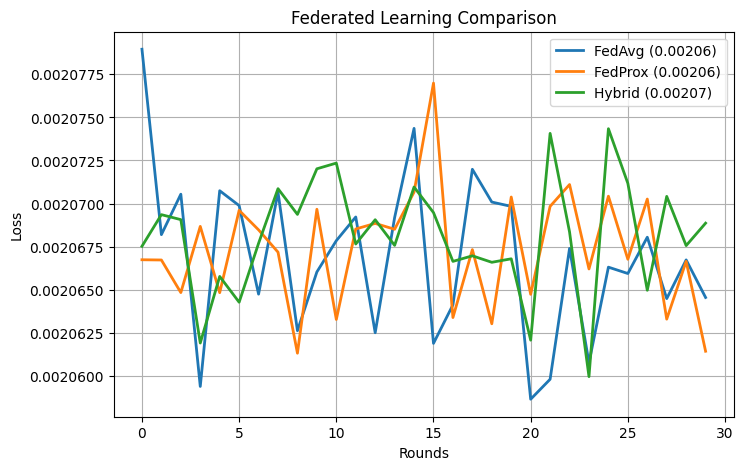

In [15]:
plt.figure(figsize=(8,5))

plt.plot(loss_fedavg, label=f"FedAvg ({loss_fedavg[-1]:.5f})", linewidth=2)
plt.plot(loss_fedprox, label=f"FedProx ({loss_fedprox[-1]:.5f})", linewidth=2)
plt.plot(loss_hybrid, label=f"Hybrid ({loss_hybrid[-1]:.5f})", linewidth=2)

plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.title("Federated Learning Comparison")
plt.legend()
plt.grid(True)
plt.show()

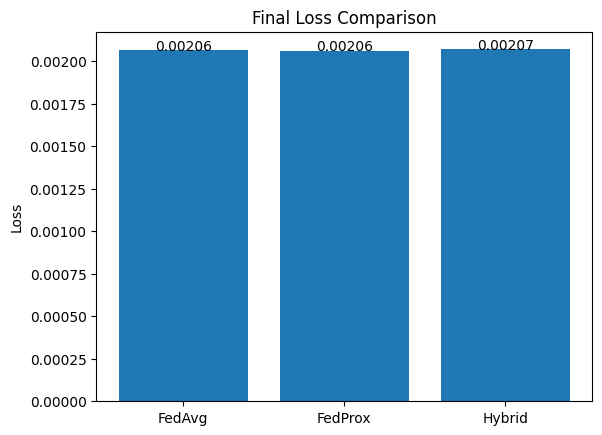

In [16]:
final_losses = [
    loss_fedavg[-1],
    loss_fedprox[-1],
    loss_hybrid[-1]
]

labels = ["FedAvg", "FedProx", "Hybrid"]

plt.figure()
bars = plt.bar(labels, final_losses)

# Add values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.5f}", ha='center')

plt.title("Final Loss Comparison")
plt.ylabel("Loss")
plt.show()

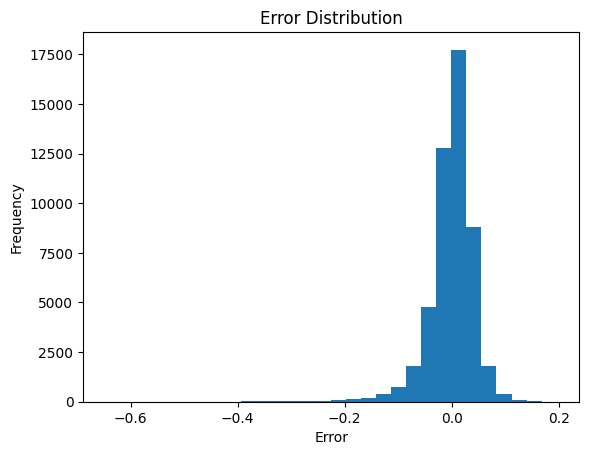

In [17]:
errors = y - y_pred

plt.figure()
plt.hist(errors, bins=30)

plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

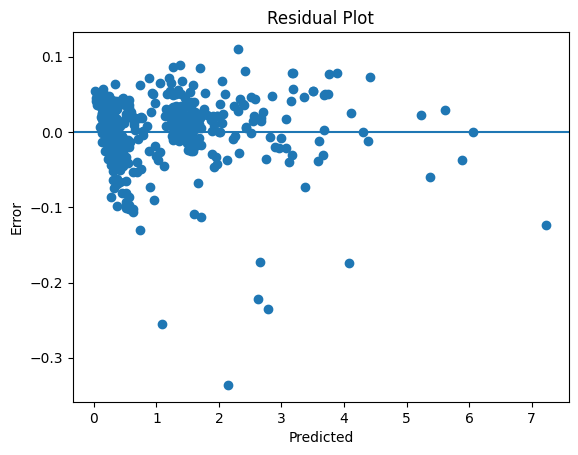

In [18]:
plt.figure()

plt.scatter(y_pred[:500], errors[:500])
plt.axhline(y=0)

plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Error")
plt.show()

In [19]:
# FedAvg Prediction
model_fedavg = Ridge(alpha=1.0)
model_fedavg.coef_ = global_weights_fedavg
model_fedavg.intercept_ = global_model.intercept_
y_pred_fedavg = model_fedavg.predict(X)

# FedProx Prediction
model_fedprox = Ridge(alpha=1.0)
model_fedprox.coef_ = global_weights_fedprox
model_fedprox.intercept_ = global_model.intercept_
y_pred_fedprox = model_fedprox.predict(X)

# Hybrid Prediction
model_hybrid = Ridge(alpha=1.0)
model_hybrid.coef_ = global_weights_hybrid
model_hybrid.intercept_ = global_model.intercept_
y_pred_hybrid = model_hybrid.predict(X)

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

metrics_fedavg = evaluate(y, y_pred_fedavg)
metrics_fedprox = evaluate(y, y_pred_fedprox)
metrics_hybrid = evaluate(y, y_pred_hybrid)

In [21]:
print("\nEvaluation Metrics:\n")

print("FedAvg:")
print(f"MSE={metrics_fedavg[0]:.6f}, RMSE={metrics_fedavg[1]:.6f}, MAE={metrics_fedavg[2]:.6f}, R2={metrics_fedavg[3]:.6f}")

print("\nFedProx:")
print(f"MSE={metrics_fedprox[0]:.6f}, RMSE={metrics_fedprox[1]:.6f}, MAE={metrics_fedprox[2]:.6f}, R2={metrics_fedprox[3]:.6f}")

print("\nHybrid:")
print(f"MSE={metrics_hybrid[0]:.6f}, RMSE={metrics_hybrid[1]:.6f}, MAE={metrics_hybrid[2]:.6f}, R2={metrics_hybrid[3]:.6f}")


Evaluation Metrics:

FedAvg:
MSE=0.001963, RMSE=0.044306, MAE=0.029524, R2=0.998246

FedProx:
MSE=0.001963, RMSE=0.044306, MAE=0.029531, R2=0.998246

Hybrid:
MSE=0.001963, RMSE=0.044307, MAE=0.029527, R2=0.998246


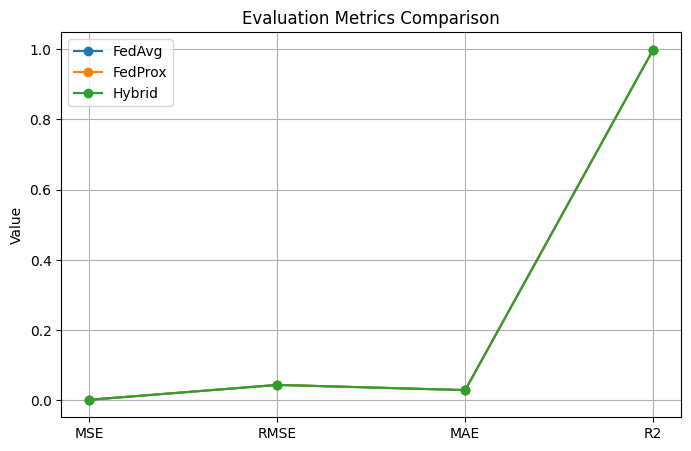

In [22]:
labels = ["MSE", "RMSE", "MAE", "R2"]

fedavg_vals = list(metrics_fedavg)
fedprox_vals = list(metrics_fedprox)
hybrid_vals = list(metrics_hybrid)

x = np.arange(len(labels))

plt.figure(figsize=(8,5))

plt.plot(x, fedavg_vals, marker='o', label="FedAvg")
plt.plot(x, fedprox_vals, marker='o', label="FedProx")
plt.plot(x, hybrid_vals, marker='o', label="Hybrid")

plt.xticks(x, labels)
plt.title("Evaluation Metrics Comparison")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

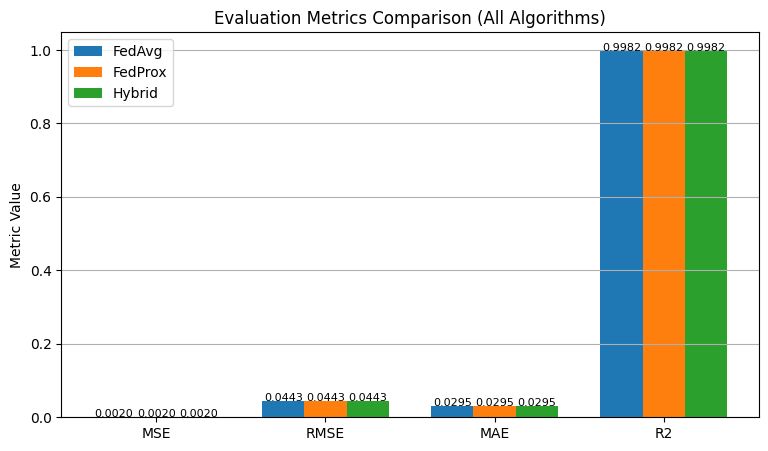

In [23]:
import numpy as np
import matplotlib.pyplot as plt

labels = ["MSE", "RMSE", "MAE", "R2"]

fedavg_vals = list(metrics_fedavg)
fedprox_vals = list(metrics_fedprox)
hybrid_vals = list(metrics_hybrid)

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(9,5))

bars1 = plt.bar(x - width, fedavg_vals, width, label="FedAvg")
bars2 = plt.bar(x, fedprox_vals, width, label="FedProx")
bars3 = plt.bar(x + width, hybrid_vals, width, label="Hybrid")

# Add values on top
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, f"{yval:.4f}", ha='center', fontsize=8)

plt.xticks(x, labels)
plt.ylabel("Metric Value")
plt.title("Evaluation Metrics Comparison (All Algorithms)")
plt.legend()
plt.grid(axis='y')

plt.show()

In [24]:
client_means = [np.mean(y_client) for _, y_client in client_data]

In [25]:
def personalized_predict(X_input, client_id=0):

    model = Ridge(alpha=1.0)
    model.coef_ = global_weights_hybrid
    model.intercept_ = global_model.intercept_

    pred = model.predict(X_input.reshape(1, -1))[0]

    return pred

In [30]:
sample = X[0]
client_id = 3   # simulate user
pred = personalized_predict(sample, client_id)
print("Prediction:", pred)

Prediction: 0.1771152482023124
